# ANALISIS EXPLORATIRO DE DATOA (EDA)

## 1. El problema del negocio

¿Que perfil tienen los clientes con mayor potencial de conversion?

Es el problema de negocio que quiere determinar una entidad bancaria al contratar una empresa de analisis de datos que se encargue en contactar telefonicamente y mediante los datos a posibles clientes para determinar si estan interesados o no en adquirir un certificado de deposito a termino con el banco (entidad bancaria)

## 2. El set de datos

La informacion recolecta por la empresa se encuentra en un archivo CSV (dataset_banco.csv) con 45215 filas y 17 columnas

1. "age":  edad (numérica)
2. "job": tipo de trabajo (categórica: "admin.", "unknown", "unemployed", "management", "housemaid", "entrepreneur", "student", "blue-collar","self-employed", "retired", "technician", "services")
3. "marital": estado civil (categórica: "married", "divorced", "single")
4. "education": nivel educativo (categórica: "unknown", "secondary", "primary", "tertiary")
5. "default": si dejó de pagar sus obligaciones (categórica: "yes", "no")
6. "balance": saldo promedio anual en euros (numérica)
7. "housing": ¿tiene o no crédito hipotecario? (categórica: "yes", "no")
8. "loan": ¿tiene créditos de consumo? (categórica: "yes", "no")
9. "contact": medio a través del cual fue contactado (categórica: "unknown", "telephone", "cellular")
10. "day": último día del mes en el que fue contactada (numérica)
11. "month": último mes en el que fue contactada (categórica: "jan", "feb", "mar", ..., "nov", "dec")
12. "duration": duración (en segundos) del último contacto (numérica)
13. "campaign": número total de veces que fue contactada durante la campaña (numérica)
14. "pdays": número de días transcurridos después de haber sido contactado antes de la campaña actual (numérica. -1 indica que no fue contactado previamente)
15. "previous": número de veces que ha sido contactada antes de esta campaña (numérica)
16. "poutcome": resultado de la campaña de marketing anterior (categórica: "unknown", "other", "failure", "success")
17. "y": categoría ¿el cliente se suscribió a un depósito a término? (categórica: "yes", "no")

## 3. Explorando el dataset

In [2]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# lectura del dataset
data = pd.read_csv('../data/dataset_banco_limpio.csv')
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45184,51,technician,married,tertiary,no,825.0,no,no,cellular,17,nov,977.0,3,-1.0,0,unknown,yes
45185,71,retired,divorced,primary,no,1729.0,no,no,cellular,17,nov,456.0,2,-1.0,0,unknown,yes
45186,72,retired,married,secondary,no,5715.0,no,no,cellular,17,nov,1127.0,5,184.0,3,success,yes
45187,57,blue-collar,married,secondary,no,668.0,no,no,telephone,17,nov,508.0,4,-1.0,0,unknown,no


## 4. Analisis Exploratorio

La idea es usar herramientas estadisticas y de visualizacion para:

- Crear un mapa mental del set de datos (entenderlo)
- Empezar a encontrar respuestas a la pregunta planteada inicialmente (¿que perfil tiene los clientes con mayor potencial de conversion?)

LLevaremos a cabo estas fases:

1. Analisis de cada variable de manera individual
2. Analisis univariado: relaion de cada variable predictora con la variable a predecir
3. Analisis bivariado: relacion de pares de variables predictoras con la variable a predecir

### 4.1 Analisis de cada variable d emanera individual

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45189 entries, 0 to 45188
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45189 non-null  int64  
 1   job        45189 non-null  str    
 2   marital    45189 non-null  str    
 3   education  45189 non-null  str    
 4   default    45189 non-null  str    
 5   balance    45189 non-null  float64
 6   housing    45189 non-null  str    
 7   loan       45189 non-null  str    
 8   contact    45189 non-null  str    
 9   day        45189 non-null  int64  
 10  month      45189 non-null  str    
 11  duration   45189 non-null  float64
 12  campaign   45189 non-null  int64  
 13  pdays      45189 non-null  float64
 14  previous   45189 non-null  int64  
 15  poutcome   45189 non-null  str    
 16  y          45189 non-null  str    
dtypes: float64(3), int64(4), str(10)
memory usage: 5.9 MB


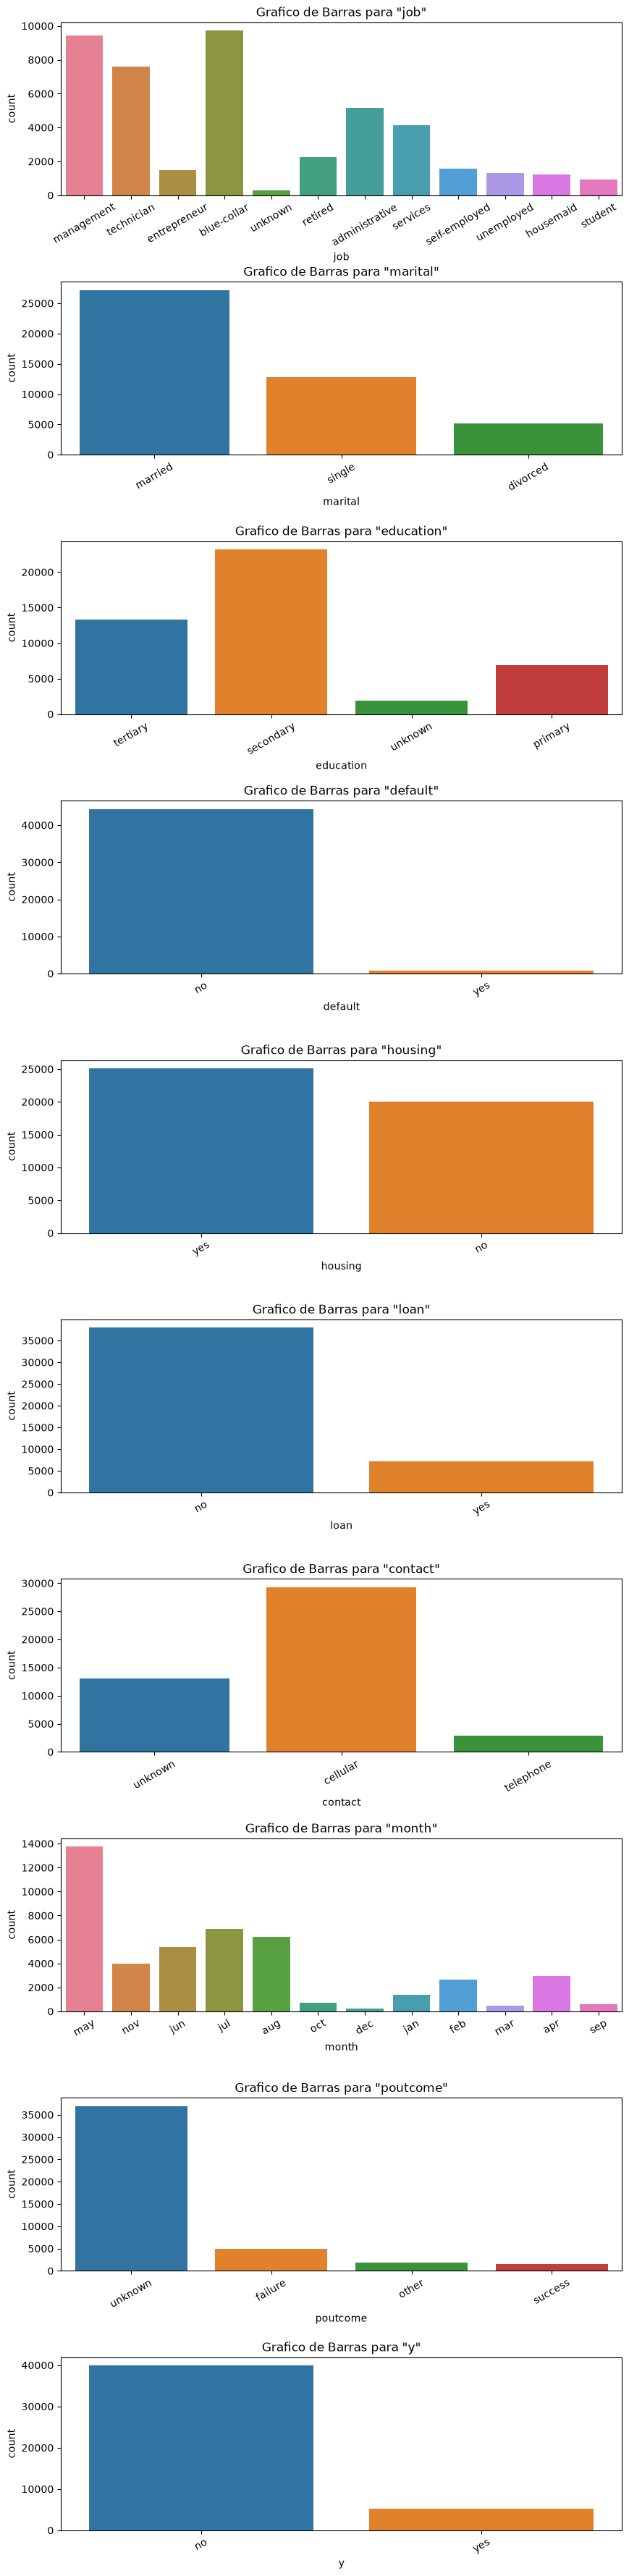

In [9]:
# tomar las variables categoricas y generar grafico barras
col_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
# grafica de barras
fig, ax = plt.subplots(nrows=len(col_cat), ncols=1, figsize=(10, 45))
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(col_cat):
    sns.countplot(data=data, x=col, ax=ax[i], hue=col)
    ax[i].set_title(f'Grafico de Barras para \"{col}\"')
    ax[i].set_xticks(ax[i].get_xticks())
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30)

plt.show()

In [11]:
# Eliminar las columnas contact, month, day, duration. campaign, pdays. previous
# pues no aportan informacion relevante para el EDA sobre el cliente
data.drop(columns=['contact', 'month', 'day', 'duration', 'campaign', 'pdays', 'previous'], inplace=True)
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'poutcome', 'y'],
      dtype='str')

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45189 entries, 0 to 45188
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45189 non-null  int64  
 1   job        45189 non-null  str    
 2   marital    45189 non-null  str    
 3   education  45189 non-null  str    
 4   default    45189 non-null  str    
 5   balance    45189 non-null  float64
 6   housing    45189 non-null  str    
 7   loan       45189 non-null  str    
 8   poutcome   45189 non-null  str    
 9   y          45189 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.4 MB


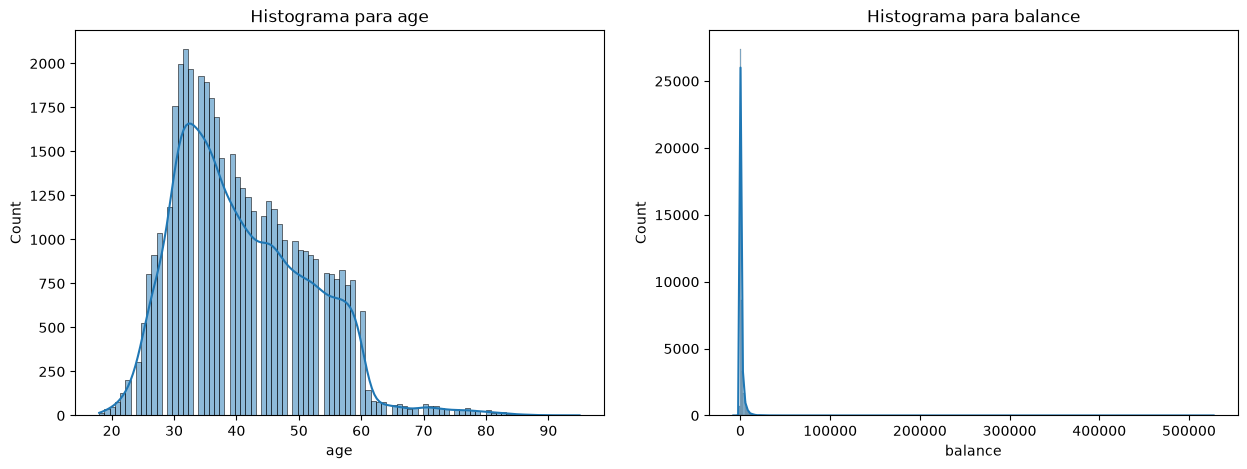

In [14]:
# dibujar un histograma para cada variable numerica
col_num = ['age', 'balance']
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig. subplots_adjust(hspace=0.5)

for i, col in enumerate(col_num):
    sns.histplot(data=data, x=col, ax=ax[i], kde=True)
    ax[i].set_title(f'Histograma para {col}')

plt.show()

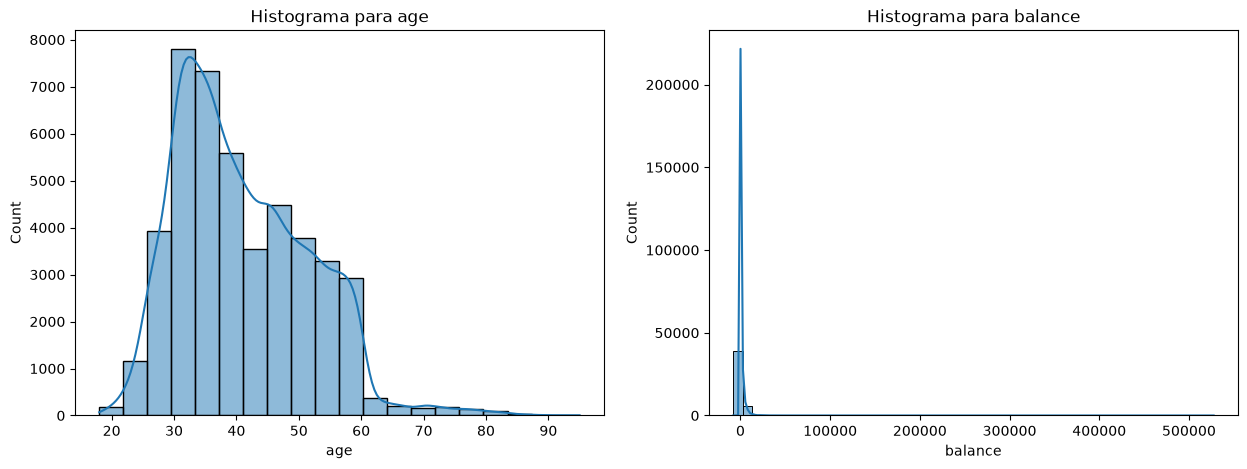

In [21]:
# dibujar un histograma para cada variable numerica
col_num = ['age', 'balance']
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig. subplots_adjust(hspace=0.5)

for i, col in enumerate(col_num):
    if col == 'age':
        nb = 20
    else:
        nb = 50
    sns.histplot(data=data, x=col, ax=ax[i], bins=nb, kde=True)
    ax[i].set_title(f'Histograma para {col}')

plt.show()

In [22]:
data['balance'].describe()

count     45189.000000
mean       1374.012149
std        3924.370039
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      527532.000000
Name: balance, dtype: float64

### 4.2 Analisis univariado

In [23]:
data

,age,job,marital,education,default,balance,housing,loan,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,no
...,...,...,...,...,...,...,...,...,...,...
45184,51,technician,married,tertiary,no,825.0,no,no,unknown,yes
45185,71,retired,divorced,primary,no,1729.0,no,no,unknown,yes
45186,72,retired,married,secondary,no,5715.0,no,no,success,yes
45187,57,blue-collar,married,secondary,no,668.0,no,no,unknown,no


In [24]:
data['y'].value_counts()

y
no     39904
yes     5285
Name: count, dtype: int64

In [26]:
# comencemos representando la varible a predecir de forma binaria:
# yes = 1 , no = 0
binario = data['y'].map({'yes':1, 'no':0})
data['y_bin'] = binario

In [27]:
data

,age,job,marital,education,default,balance,housing,loan,poutcome,y,y_bin
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,no,0
1,44,technician,single,secondary,no,29.0,yes,no,unknown,no,0
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,no,0
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,no,0
4,33,unknown,single,unknown,no,1.0,no,no,unknown,no,0
...,...,...,...,...,...,...,...,...,...,...,...
45184,51,technician,married,tertiary,no,825.0,no,no,unknown,yes,1
45185,71,retired,divorced,primary,no,1729.0,no,no,unknown,yes,1
45186,72,retired,married,secondary,no,5715.0,no,no,success,yes,1
45187,57,blue-collar,married,secondary,no,668.0,no,no,unknown,no,0


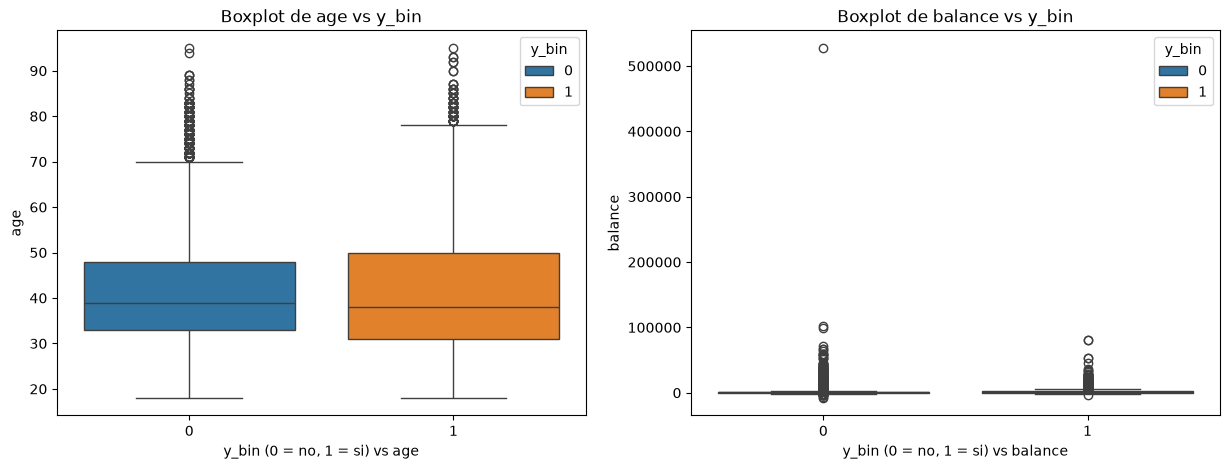

In [29]:
# analizar la realacion entre las variables numericas y la variable a predecir (y_bin)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(col_num):
    sns.boxplot(data=data, x='y_bin', y=col, ax=ax[i], hue='y_bin')
    ax[i].set_title(f'Boxplot de {col} vs y_bin')
    ax[i].set_xlabel(f'y_bin (0 = no, 1 = si) vs {col}')

plt.show()

In [31]:
# funcion para graficar tasas de conversion
def graficar_tasa_conversion(var_predictora, var_predecir, type='line', order=None):
    x, y = var_predictora, var_predecir
    # genear agrupaciones (groupby) y calcular la tasa de conversion (mean)
    grupo = data.groupby(x)[y].mean().rename('tasa_conv').reset_index()
    #graficar
    if type=='line':
        plt.figure(figsize=(10,6))
        sns.lineplot(data=grupo, x=x, y='tasa_conv')
        plt.grid()
    elif type=='bar':
        plt.figure(figsize=(10,6))
        sns.barplot(data=grupo, x=x, y='tasa_conv', order=order, hue=x)
        plt.grid()
    elif type=='scatter':
        plt.figure(figsize=(10,6))
        sns.scatterplot(data=grupo, x=x, y='tasa_conv')
        plt.grid()

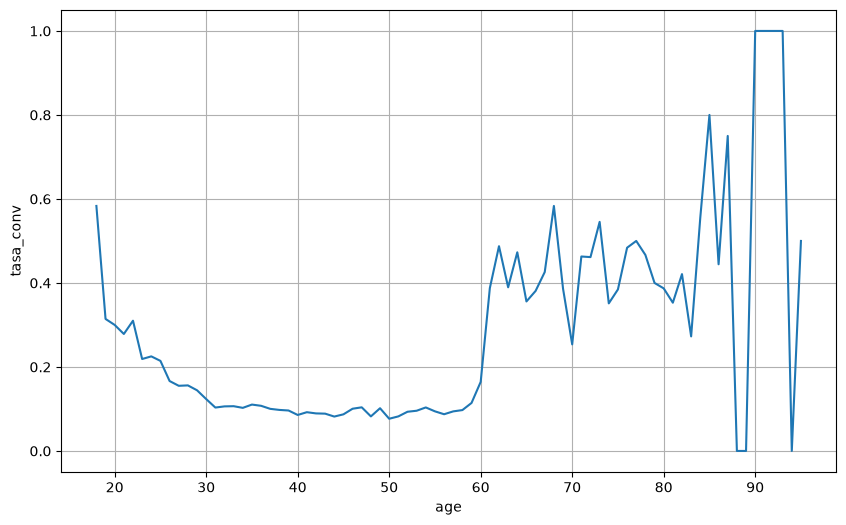

In [32]:
# graficar las tasas de conversion para la variable 'age
graficar_tasa_conversion('age', 'y_bin')

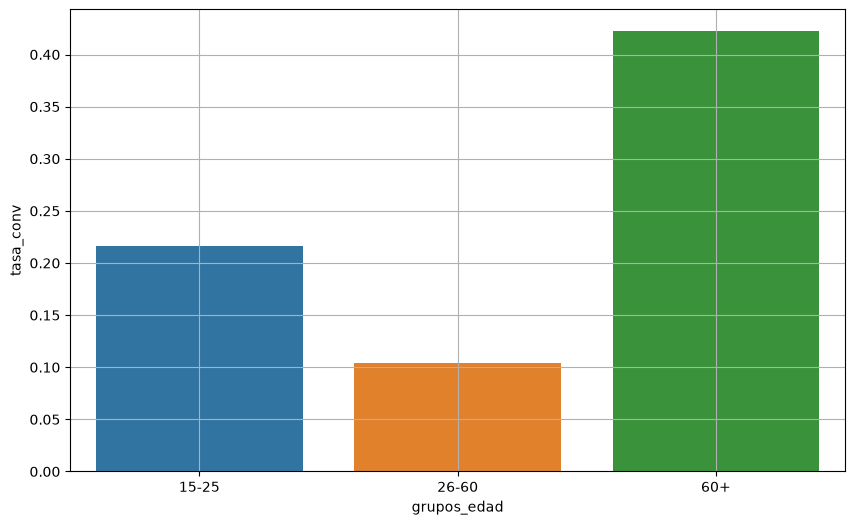

In [ ]:
# creamos subgrupos de edades y calculamos la tasa de conversion
data.loc[:,'grupos_edad'] = "15-25"
data.loc[(data['age']>25) & (data['age']<60), 'grupos_edad'] = "26-60"
data.loc[(data['age'])>60, 'grupos_edad'] = "60+"
# graficar tasa de conversion por grupos de edad
graficar_tasa_conversion('grupos_edad', 'y_bin', type='bar')

In [35]:
data

,age,job,marital,education,default,balance,housing,loan,poutcome,y,y_bin,grupos_edad
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,no,0,26-60
1,44,technician,single,secondary,no,29.0,yes,no,unknown,no,0,26-60
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,no,0,26-60
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,no,0,26-60
4,33,unknown,single,unknown,no,1.0,no,no,unknown,no,0,26-60
...,...,...,...,...,...,...,...,...,...,...,...,...
45184,51,technician,married,tertiary,no,825.0,no,no,unknown,yes,1,26-60
45185,71,retired,divorced,primary,no,1729.0,no,no,unknown,yes,1,60+
45186,72,retired,married,secondary,no,5715.0,no,no,success,yes,1,60+
45187,57,blue-collar,married,secondary,no,668.0,no,no,unknown,no,0,26-60


In [36]:
# eliminamos la columna "age" (dejando solo los grupos de edad)
data.drop(columns=['age'], inplace=True)

In [37]:
data

,job,marital,education,default,balance,housing,loan,poutcome,y,y_bin,grupos_edad
0,management,married,tertiary,no,2143.0,yes,no,unknown,no,0,26-60
1,technician,single,secondary,no,29.0,yes,no,unknown,no,0,26-60
2,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,no,0,26-60
3,blue-collar,married,unknown,no,1506.0,yes,no,unknown,no,0,26-60
4,unknown,single,unknown,no,1.0,no,no,unknown,no,0,26-60
...,...,...,...,...,...,...,...,...,...,...,...
45184,technician,married,tertiary,no,825.0,no,no,unknown,yes,1,26-60
45185,retired,divorced,primary,no,1729.0,no,no,unknown,yes,1,60+
45186,retired,married,secondary,no,5715.0,no,no,success,yes,1,60+
45187,blue-collar,married,secondary,no,668.0,no,no,unknown,no,0,26-60


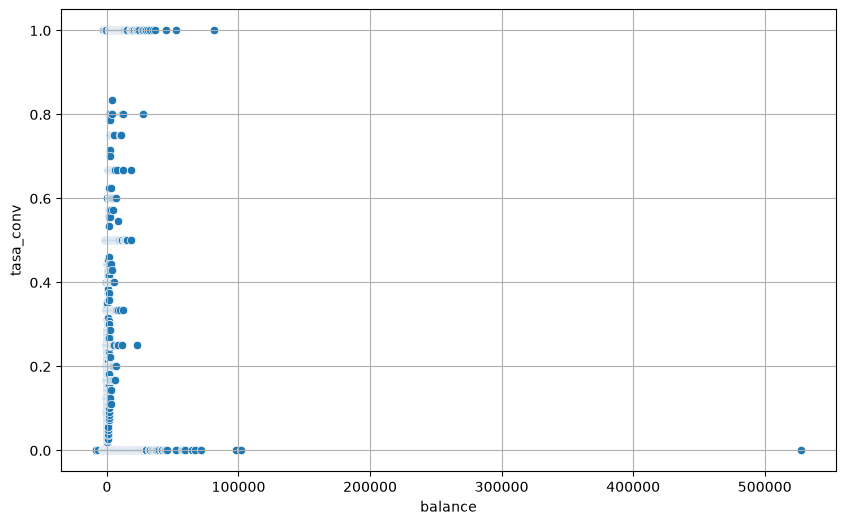

In [38]:
# realizamos el mismo analisis par ala variable "balance"
graficar_tasa_conversion('balance', 'y_bin', type='scatter')

In [ ]:
# creamos nueva columna con rangos de balance "grupos_balance"
data.loc[:,'grupos_balance'] = "<0"
data.loc[(data['balance'] >= 0) & (data['balance'] < 4000), 'grupos_balance'] = "0-4k"
data.loc[(data['balance'] >= 4000) & (data['balance'] < 8000), 'grupos_balance'] = "4k-8k"
data.loc[(data['balance'] >= 8000) & (data['balance'] < 12000), 'grupos_balance'] = "8k-12k"
data.loc[(data['balance'] >= 12000) & (data['balance'] < 16000), 'grupos_balance'] = "12k-16k"
data.loc[(data['balance'] >= 16000) & (data['balance'] < 20000), 'grupos_balance'] = "16k-20k"
data.loc[(data['balance'] >= 20000), 'grupos_balance'] = "20k+"

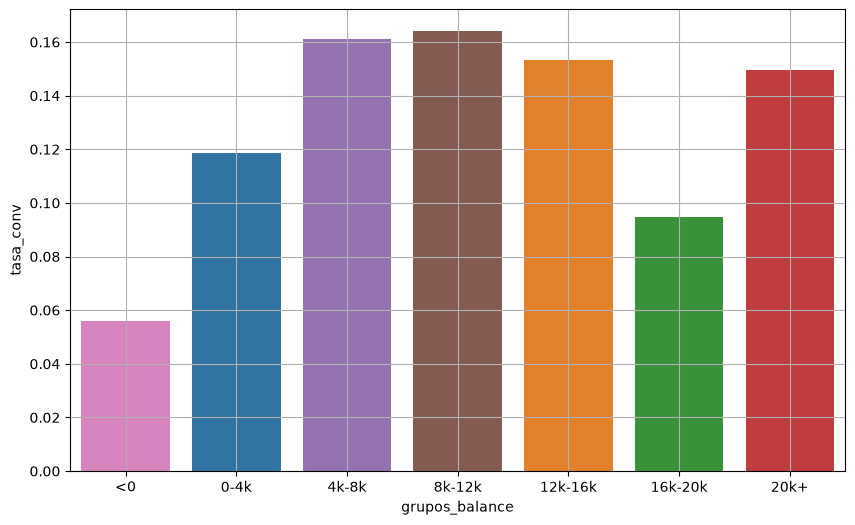

In [42]:
#graficar tasas de conversion por grupos balance
orden = ["<0", "0-4k", "4k-8k", "8k-12k", "12k-16k", "16k-20k", "20k+"]
graficar_tasa_conversion('grupos_balance', 'y_bin', type='bar', order=orden)